Problem1

In [ ]:

import math
x=0.5
y=(1.0,0.5)#y1,y2
lrate=0.1
W_xh1,W_xh2,W_h1y1,W_h1y2,W_h2y1,W_h2y2=(0.2,0.1,0.2,0.2,0.5,0.4)
def sigma(x):
    return 1/(math.exp(-1*x)+1)
#forward
h1_input=x*W_xh1
h2_input=x*W_xh2
h1=sigma(h1_input)
h2=sigma(h2_input)
y1_input=h1*W_h1y1+h2*W_h2y1
y2_input=h2*W_h2y2+h1*W_h1y2
y1=sigma(y1_input)
y2=sigma(y2_input)
L=(1.0-y1)**2+(0.5-y2)**2
#backward
delta_y1=2*(y1-1.0)*y1*(1-y1)
delta_y2=2*(y2-0.5)*y2*(1-y2)
delta_h1=(delta_y1*W_h1y1+delta_y2*W_h1y2)*h1*(1-h1)
delta_h2=(delta_y1*W_h2y1+delta_y2*W_h2y2)*h2*(1-h2)
W_h1y1=W_h1y1-lrate*delta_y1*h1
W_h1y2=W_h1y2-lrate*delta_y2*h1
W_h2y1=W_h2y1-lrate*delta_y1*h2
W_h2y2=W_h2y2-lrate*delta_y2*h2
W_xh1=W_xh1-lrate*delta_h1*x
W_xh2=W_xh2-lrate*delta_h2*x
#new weights after 1 epoch
print(W_xh1,W_xh2,W_h1y1,W_h1y2,W_h2y1,W_h2y2)

0.2004020949769855 0.10105401005016737 0.2104351935357101 0.19802959298283135 0.5101870886435376 0.39807644095156886


problem2 强化学习


In [ ]:


states = ["S1", "S2", "S3"]
actions = ["A1", "A2", "A3"]  # A1: left 20cm, A2: ahead 20cm, A3: right 20cm

# Q-table
Q = {
    "S1": {"A1": 0.5, "A2": 0.2, "A3": 1.0},
    "S2": {"A1": 2.0, "A2": 3.0, "A3": 0.5},
    "S3": {"A1": 2.0, "A2": 0.5, "A3": -0.1}
}

# Rewards for each corrected state
reward = {
    "S1": -5,
    "S2": 5,
    "S3": -5
}

# Parameters
alpha = 0.2   # learning rate
gamma = 0.5   # discount factor

# Initial condition: robot is 15 cm right deviated from centerline
position = 15
current_state = "S3"

# Choose action with maximum Q-value in current state
current_action = max(Q[current_state], key=Q[current_state].get)

# State transition after one step
if current_action == "A1":      # step left 20 cm
    new_position = position - 20
elif current_action == "A2":    # step ahead 20 cm
    new_position = position
else:                           # A3: step right 20 cm
    new_position = position + 20

# Determine next state
if new_position < -10:
    next_state = "S1"
elif -10 <= new_position <= 10:
    next_state = "S2"
else:
    next_state = "S3"

# Get reward from next state
r = reward[next_state]

# Q-learning update
old_q = Q[current_state][current_action]
max_next_q = max(Q[next_state].values())

new_q = old_q + alpha * (r + gamma * max_next_q - old_q)
Q[current_state][current_action] = new_q

# Print results
print("Current state:", current_state)
print("Chosen action:", current_action)
print("New position:", new_position, "cm")
print("Next state:", next_state)
print("Reward:", r)
print("Updated Q-value:", new_q)

print("\nUpdated Q-table:")
for s in states:
    print(s, Q[s])




Current state: S3
Chosen action: A1
New position: -5 cm
Next state: S2
Reward: 5
Updated Q-value: 2.9

Updated Q-table:
S1 {'A1': 0.5, 'A2': 0.2, 'A3': 1.0}
S2 {'A1': 2.0, 'A2': 3.0, 'A3': 0.5}
S3 {'A1': 2.9, 'A2': 0.5, 'A3': -0.1}


In [ ]:
#pandas 把这个result做成表格
import pandas as pd
q_table={"S1":{'A1': 0.5, 'A2': 0.2, 'A3': 1.0}
,"S2":{'A1': 2.0, 'A2': 3.0, 'A3': 0.5},
"S3":{'A1': 2.9, 'A2': 0.5, 'A3': -0.1}}
df=pd.DataFrame(q_table)
df=df.T
print(df)

     A1   A2   A3
S1  0.5  0.2  1.0
S2  2.0  3.0  0.5
S3  2.9  0.5 -0.1


problem3
（用的pytorch）


Training the model...
Epoch 10/500, Loss: 7988.3706
Epoch 20/500, Loss: 4019.0633
Epoch 30/500, Loss: 2295.9164
Epoch 40/500, Loss: 1475.8518
Epoch 50/500, Loss: 1032.7758
Epoch 60/500, Loss: 700.1426
Epoch 70/500, Loss: 453.3923
Epoch 80/500, Loss: 278.8789
Epoch 90/500, Loss: 173.2819
Epoch 100/500, Loss: 110.8323
Epoch 110/500, Loss: 73.7904
Epoch 120/500, Loss: 55.6888
Epoch 130/500, Loss: 43.8306
Epoch 140/500, Loss: 35.7803
Epoch 150/500, Loss: 32.8387
Epoch 160/500, Loss: 25.3554
Epoch 170/500, Loss: 20.5338
Epoch 180/500, Loss: 18.5579
Epoch 190/500, Loss: 18.5992
Epoch 200/500, Loss: 14.1068
Epoch 210/500, Loss: 12.6954
Epoch 220/500, Loss: 11.7813
Epoch 230/500, Loss: 10.4349
Epoch 240/500, Loss: 10.0911
Epoch 250/500, Loss: 9.7202
Epoch 260/500, Loss: 10.6930
Epoch 270/500, Loss: 8.7215
Epoch 280/500, Loss: 8.3770
Epoch 290/500, Loss: 6.8690
Epoch 300/500, Loss: 5.7067
Epoch 310/500, Loss: 5.4429
Epoch 320/500, Loss: 5.4956
Epoch 330/500, Loss: 5.5676
Epoch 340/500, Loss: 4.

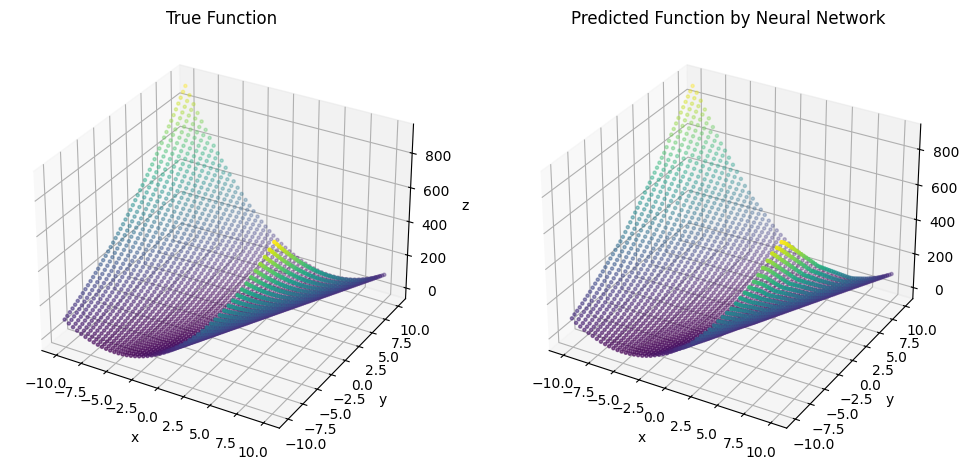

In [19]:

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Generate training data
def generate_data(num_samples=1000):
    x = np.random.uniform(-10, 10, num_samples)
    y = np.random.uniform(-10, 10, num_samples)
    z = (2*x-y)**2
    return x, y, z

# Build the neural network
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        #神经网络结构

    def forward(self, x):
        return self.model(x)

# Train the neural network
def train_model(model, x_train, y_train, z_train, epochs=500, batch_size=64, lr=0.003):
    inputs = np.stack((x_train, y_train), axis=1).astype(np.float32)
    targets = z_train.astype(np.float32).reshape(-1, 1)

    dataset = TensorDataset(torch.tensor(inputs), torch.tensor(targets))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch_inputs, batch_targets in dataloader:
            optimizer.zero_grad()
            predictions = model(batch_inputs)
            loss = criterion(predictions, batch_targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch_inputs.size(0)

        epoch_loss /= len(dataset)
        losses.append(epoch_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}")

    return losses

# Test the neural network
def test_model(model, x_test, y_test):
    inputs = np.stack((x_test, y_test), axis=1).astype(np.float32)
    inputs_tensor = torch.tensor(inputs)

    model.eval()
    with torch.no_grad():
        z_pred = model(inputs_tensor).cpu().numpy()
    return z_pred

# Main function
def main():
    x_train, y_train, z_train = generate_data(1000)

    model = NeuralNetwork()

    print("Training the model...")
    train_model(model, x_train, y_train, z_train, epochs=500)

    print("Testing the model...")
    x_test, y_test = np.meshgrid(np.linspace(-10, 10, 50), np.linspace(-10, 10, 50))
    x_test_flat = x_test.ravel()
    y_test_flat = y_test.ravel()
    z_true = (2*x_test_flat - y_test_flat)**2
    z_pred = test_model(model, x_test_flat, y_test_flat).ravel()

    fig = plt.figure(figsize=(12, 6))

    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(x_test_flat, y_test_flat, z_true, c=z_true, cmap='viridis', s=5)
    ax1.set_title('True Function')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('z')

    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(x_test_flat, y_test_flat, z_pred, c=z_pred, cmap='viridis', s=5)
    ax2.set_title('Predicted Function by Neural Network')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_zlabel('z')

    plt.show()

# Run the main function
if __name__ == "__main__":
    main()


训练轮次500轮，loss=2.95,每次喂64个数据，学习率0.003，神经网络2->32->32->1